In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
from scipy.linalg import eigh, cholesky
from scipy.stats import norm
import linearmodels.panel as lmp
from pylab import plot, show, axis, subplot, xlabel, ylabel, grid
import semopy 
import seaborn as sns
from factor_analyzer import FactorAnalyzer
from sklearn.decomposition import PCA
from IPython.display import Image
import math

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

In [2]:
df = pd.read_csv('../../../data/junaeb3.csv', delimiter=",", decimal='.')

<font size="3">**Tarea 3**</font>

<u> *Instrucciones* </u>

Los resultados de los ejericicios propuestos se deben entregar como un notebook por correo electronico a *juancaros@udec.cl* el dia 6/6 hasta las 21:00. Es importante considerar que el código debe poder ejecutarse en cualquier computadora con la data original del repositorio. Recordar la convencion para el nombre de archivo ademas de incluir en su documento titulos y encabezados por seccion. Utilizar la base de datos junaeb3.csv, el diccionario de datos es el siguiente:

- sexo: sexo del estudiante (1: mujer)
- edad: edad del estudiante (meses)
- imce: indice de masa corporal estandarizado (puntaje z)
- vive_padre: 1 si el padre vive en el hogar (2 indica que tiene mas de un padre)
- vive_madre: 2 si la madre vive en el hogar (2 indica que tiene mas de una madre)
- area: urbana=1, rural=0
- sk1: muestra afecto a padres (1: siempre - 5: nunca)
- sk2: muestra afecto a sus pares (1: siempre - 5: nunca)
- sk3: expresa sus sentimientos (1: siempre - 5: nunca)
- sk4: usa gestos para mostrar sentimientos (1: siempre - 5: nunca)
- sk5: juega con otros (1: siempre - 5: nunca)
- sk6: comparte sus cosas con otros (1: siempre - 5: nunca)
- sk7: es agresivo (1: siempre - 5: nunca)
- sk8: participa en juegos grupales (1: siempre - 5: nunca)
- sk9: hace preguntas a adultos (1: siempre - 5: nunca) 
- sk10: tiene interes por libros (1: siempre - 5: nunca) 
- sk11: tiene interes por su entorno (1: siempre - 5: nunca)
- sk12: juega a armar y desarmar cosas (1: siempre - 5: nunca) 
- sk13: tiene expresiones artisticas (1: siempre - 5: nunca) 
- act_fisica: frecuencia actividad fisica (1: nunca - 5: 5 o mas veces a la semana)
- educm: años de escolaridad de la madre
- educp: años de escolaridad del padre
- madre_work: si la madre trabaja (-1: labor domestica, 0: desempleada, 1: empleada)

Preguntas:

1. Cargue la base de datos y realice los ajustes necesarios para su uso (missing values, recodificar variables, etcetera). Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario. 

__R:__ Se leyeron los datos con pandas, para luego realizar una limpieza que consistio en:
-Hacer un drop.na() al dataframe para eliminar columnas con valores faltantes (menor al 10% del total de los datos)
-Eliminar los valores "2" en "vive_padre" y "vive_madre" debido a la poca cantidad de los mismos
Para hacer un analisis del resto de las variables se realizo un gráfico para ver sus distribuciones de una forma más clara.


In [3]:
df

,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk9,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work
0,1,85,0.75,1,1,1,1,1,2,1,...,2,2,2,3,2,NaN,0,11.0,11,-1
1,0,76,0.71,0,1,1,1,1,1,1,...,1,1,1,1,1,5.0,0,8.0,8,1
2,1,68,0.27,0,1,2,2,3,2,1,...,2,3,2,1,3,NaN,1,13.0,13,1
3,1,84,2.05,1,1,1,1,1,1,1,...,1,1,1,1,1,2.0,1,16.0,12,-1
4,0,86,1.05,1,1,1,1,1,1,1,...,1,1,1,1,1,1.0,1,17.0,15,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31050,0,78,1.63,1,1,1,3,1,2,2,...,2,2,2,1,1,2.0,1,13.0,13,-1
31051,1,79,2.57,1,1,1,1,2,2,1,...,1,3,2,1,4,3.0,1,18.0,19,0
31052,0,78,2.12,1,1,1,1,1,1,1,...,1,3,1,1,1,3.0,1,13.0,9,1
31053,1,78,-0.43,1,1,1,1,1,1,2,...,1,2,1,1,2,2.0,1,17.0,15,1


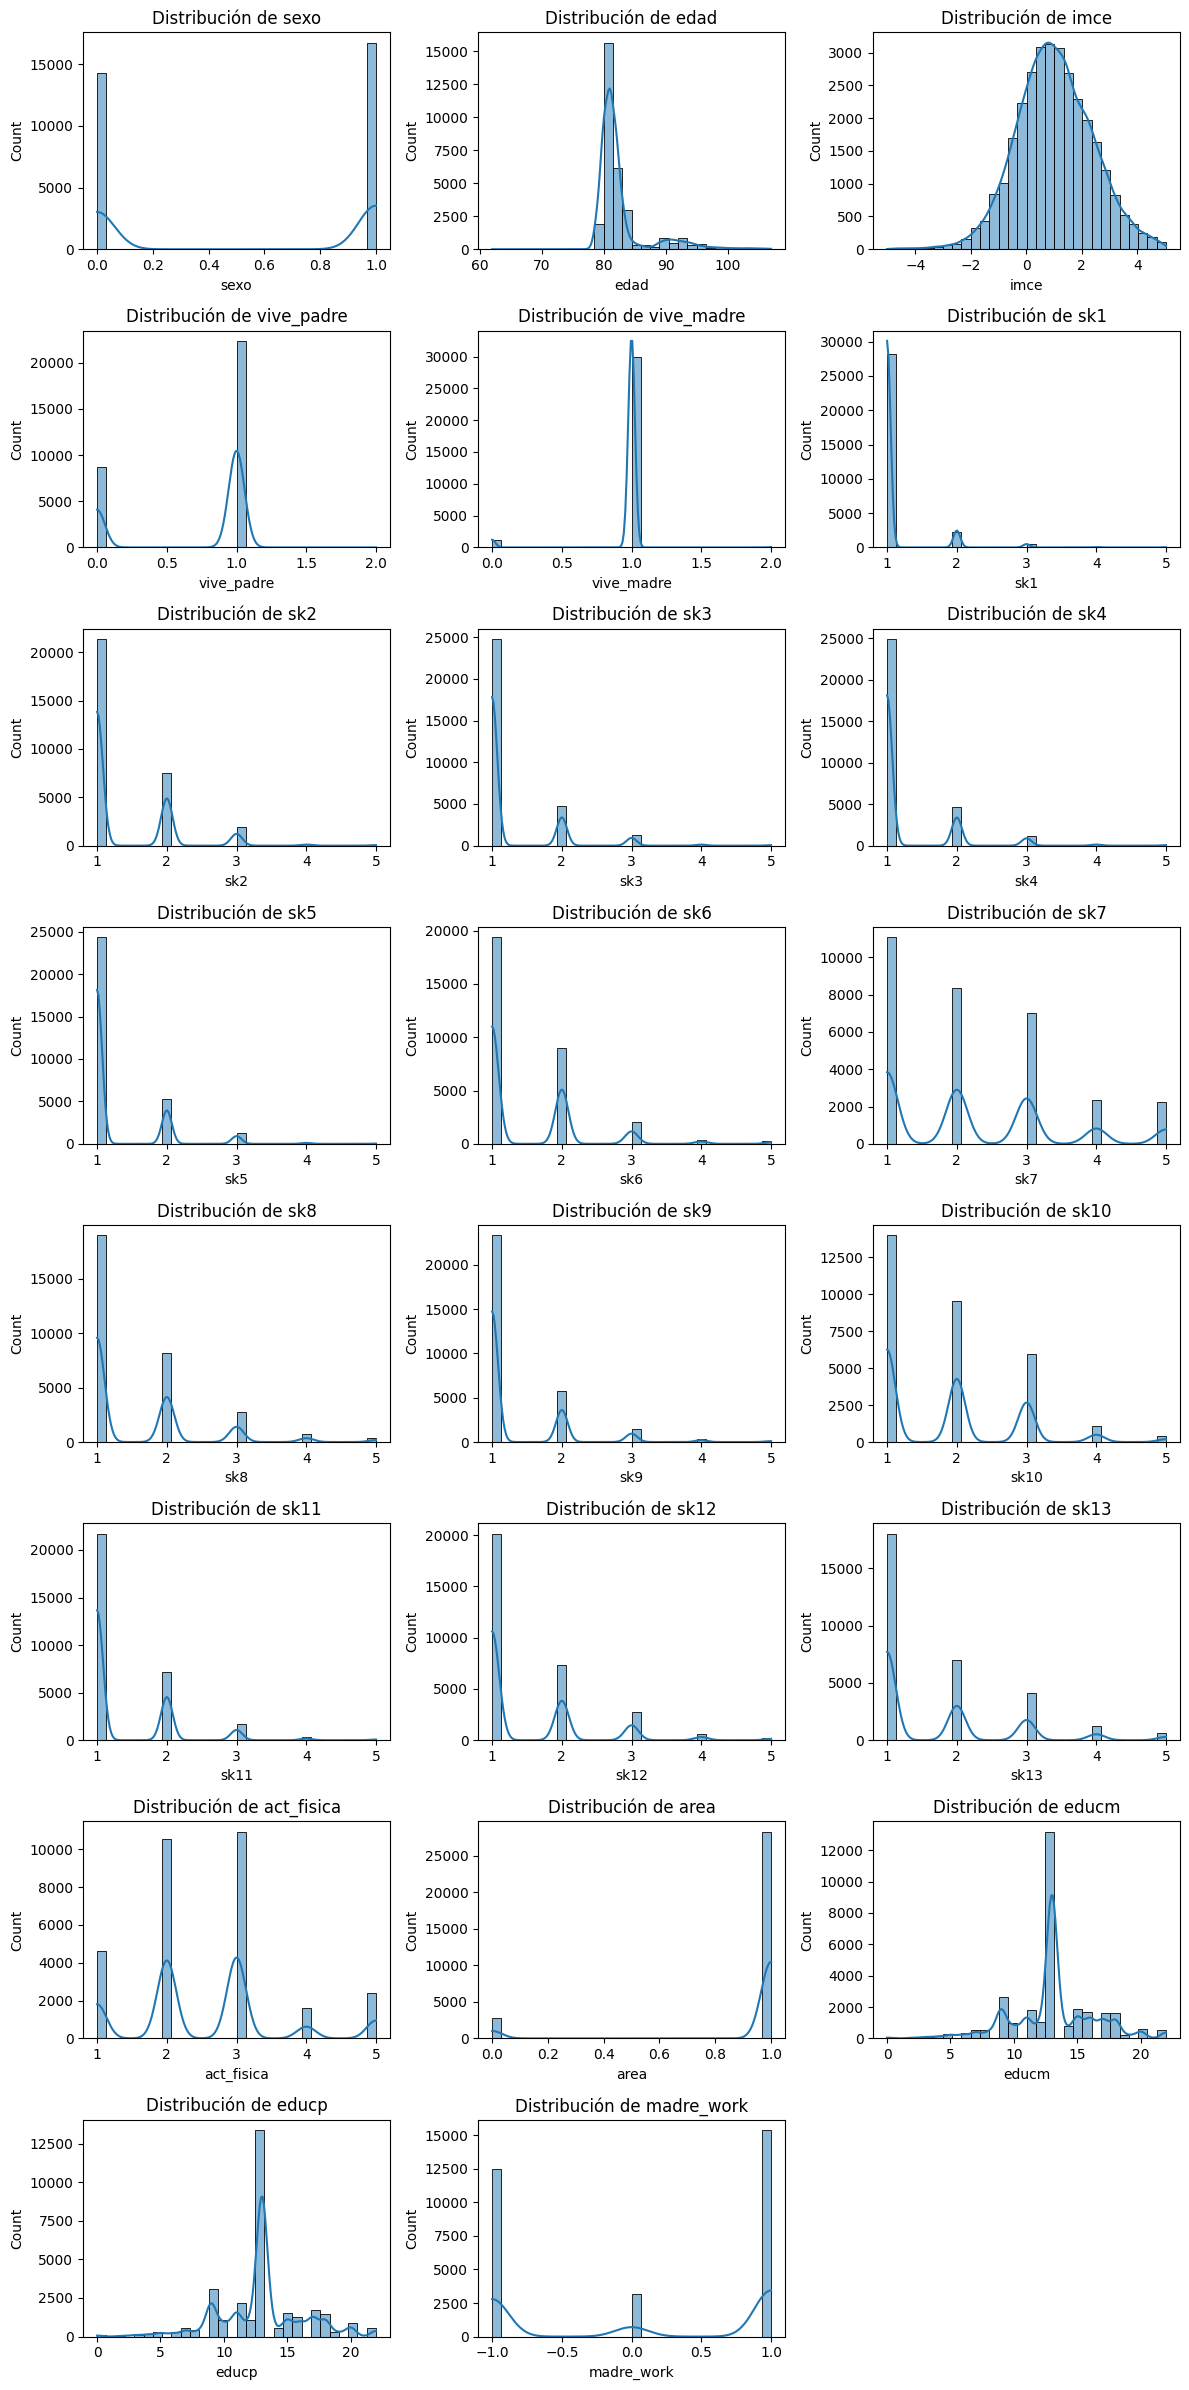

In [4]:
numeric_cols = df.select_dtypes(include='number').columns

# Configura el número de columnas por fila (por ejemplo, 2)
cols_per_row = 3
n_cols = len(numeric_cols)
n_rows = math.ceil(n_cols / cols_per_row)

# Crear una figura con subplots
fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(12, 3 * n_rows))
axes = axes.flatten()  # Para indexar fácilmente incluso si hay una sola fila

# Dibujar cada distribución
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f'Distribución de {col}')

# Eliminar subplots vacíos si sobran
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [5]:
df=df.dropna()
df = df[df['vive_padre'] != 2]
df = df[df['vive_madre'] != 2]
df.reset_index

<bound method DataFrame.reset_index of        sexo  edad  imce  vive_padre  vive_madre  sk1  sk2  sk3  sk4  sk5  ...  \
1         0    76  0.71           0           1    1    1    1    1    1  ...   
3         1    84  2.05           1           1    1    1    1    1    1  ...   
4         0    86  1.05           1           1    1    1    1    1    1  ...   
5         0    74  1.39           1           1    1    2    1    1    1  ...   
6         1    91  2.75           1           1    1    1    1    2    2  ...   
...     ...   ...   ...         ...         ...  ...  ...  ...  ...  ...  ...   
31050     0    78  1.63           1           1    1    3    1    2    2  ...   
31051     1    79  2.57           1           1    1    1    2    2    1  ...   
31052     0    78  2.12           1           1    1    1    1    1    1  ...   
31053     1    78 -0.43           1           1    1    1    1    1    2  ...   
31054     0    78 -0.55           0           1    2    2    1    1   

2. A partir de las variables sk1-sk13 realice un EFA. En particular determine el numero optimo de factores y reporte las variables que se asocian a cada factor (usando los factor loadings). Tambien discuta si existen variables que no son informativas. (Hint: para realizar un EFA, todas las variables deben estar representatadas en el mismo sentido logico. Si una carateristica es negativa debe ser invertida en la escala, de tal forma que todas las variables representen aspectos positivos).

__R:__ Para este paso se creo un dataframe alterno el cual contenia todas las columnas que empezaban con el prefijo "sk" para tener un df solamente con ese tipo de variables.
Luego se realizo un analisis de factores con el dataframe resultante usando "varimax", para cargar cada una de las variables de una forma más pronunciada en un unico factor, el resultado que se obtuvo fue de una agrupacion en 3 factores distintos, la cual fue:

FACTOR 1=sk9,sk10,sk11,sk12,sk13

Todas las variables asociadas a este factor tienen cierta relación con el interes del niño en aprender cosas, por lo cual lo vamos a nombrar "Curiosidad Intelectual"

FACTOR 2=sk1,sk2,sk3,sk4

Todos las variables asociadas a este factor tienen cierta relación con la capacidad de expresar las emociones del niño, por lo cual lo vamos a nombrar "Gestión de emociones"

FACTOR 3=sk5,sk6,sk8

Todos las variables asociadas a este factor tienen cierta relación con la forma de relacionarse del niño con sus pares, por lo cual lo vamos a nombrar "Habilidades sociales"

-La variable "sk7" la cual explicaba el nivel de agresividad del niño, resulto no ser informativa dentro de los factores.

Tambien se realizo un analisis de factores directamente desde los datos, sugiriendonos un modelo de 2 factores:

FACTOR 1 =~ sk11 + sk9 + sk10 + sk12 + sk13 + sk4
FACTOR 2 =~ sk4 + sk11 + sk2 + sk5 + sk3 + sk9 + sk1 + sk8 + sk13

Con este resultado, confirmamos que "sk7" no es una variable informativa para nuestro analisis

In [6]:
df_sk = df.loc[:, df.columns.str.startswith('sk')]

In [7]:
# Create factor analysis object and perform factor analysis
fa = FactorAnalyzer(rotation='varimax').fit(df_sk)

In [8]:
np.set_printoptions(suppress=True, formatter={'float_kind':'{:f}'.format})
fa.loadings_

array([[0.170956, 0.541000, 0.150807],
       [0.173792, 0.512760, 0.354520],
       [0.179809, 0.587227, 0.162152],
       [0.195005, 0.685408, 0.194815],
       [0.121379, 0.214461, 0.716558],
       [0.163073, 0.203981, 0.486387],
       [0.070645, 0.074728, 0.146490],
       [0.269462, 0.097361, 0.478533],
       [0.496403, 0.205356, 0.201783],
       [0.555717, 0.120762, 0.127795],
       [0.665475, 0.206294, 0.202347],
       [0.524699, 0.109824, 0.141209],
       [0.480038, 0.150919, 0.132026]])

FACTOR 1=sk9,sk10,sk11,sk12,sk13
FACTOR 2=sk1,sk2,sk3,sk4
FACTOR 3=sk5,sk6,sk8

In [9]:
fa.get_eigenvalues()

(array([4.034214, 1.352109, 1.114244, 1.000843, 0.791244, 0.706343,
        0.701189, 0.690190, 0.608368, 0.529874, 0.517230, 0.491686,
        0.462466]),
 array([3.438924, 0.747141, 0.522044, 0.216095, 0.117614, 0.062805,
        0.007217, -0.011140, -0.034171, -0.063444, -0.081942, -0.084678,
        -0.128355]))

In [10]:
fa.get_communalities()

array([0.344650, 0.418811, 0.403460, 0.545763, 0.574182, 0.304773,
       0.032034, 0.311083, 0.329303, 0.339736, 0.526358, 0.307311,
       0.270644])

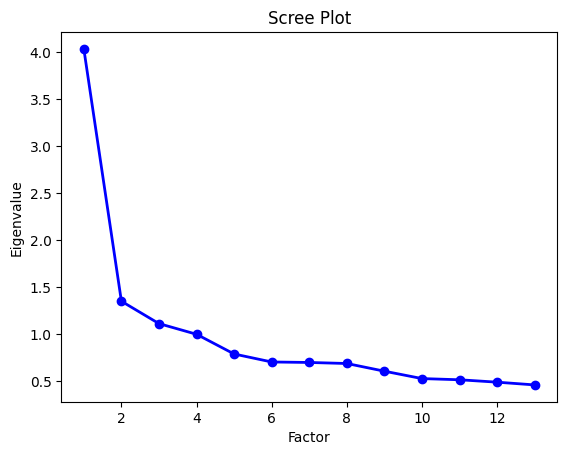

In [11]:
values = np.arange(1,14)
eigenvalues = pd.DataFrame(data=fa.get_eigenvalues())
plt.plot(values, eigenvalues.loc[0], 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Factor')
plt.ylabel('Eigenvalue')
plt.show()

In [12]:
fa.get_factor_variance()

(array([1.752553, 1.607039, 1.348517]),
 array([0.134812, 0.123618, 0.103732]),
 array([0.134812, 0.258430, 0.362162]))

In [13]:
print(semopy.efa.explore_cfa_model(df_sk, pval=0.01))

eta1 =~ sk11 + sk9 + sk10 + sk12 + sk13 + sk4
eta3 =~ sk4 + sk11 + sk2 + sk5 + sk3 + sk9 + sk1 + sk8 + sk13



3. Con los resultados de la Pregunta 2, graficamente indique si existen diferencias significativas en la distribucion de los factores usando las siguientes variables para caracterizar: sexo, area, imce y act_fisica (Hint: usar scatterplot de factores en pares, y ocupar la opcion 'hue' para agregar variables de caracterizacion). Que puede concluir de los resultados?

__R:__ Se realizo un analisis de componentes principales para determinar si es que existian diferencias entre las distribuciones de los factores, se obtuvo como resultado que:

El componente principal 1 (PC1), explica un 31.03% de la varianza total de los datos

El componente principal 2 (PC2), explica un 10.40% de la varianza total de los datos

El componente principal 3 (PC3), explica un 8.57% de la varianza total de los datos

Los 3 juntos explican el 50% de la varianza total de los datos

Luego se realizo un scatterplot comparando cada uno de los componentes entre si para 4 variables distintas:

-La variable "sexo" no muestra tendencia y parece estar completamente mezclada, por lo cual no es un factor determinante para la distribución de los individuos.

-La variable "area" tampoco muestra una tendencia clara y tambien parece estar completamente mezclada, por lo cual no es un factor determinante para la distribución de los individuos.

-La variable "imce" tampoco muestra una tendencia clara y tambien parece estar completamente mezclado, por lo cual no es un factor determinante para la distribución de los individuos.

-Por ultimo, la variable "act_fisica" tampoco muestra una tendencia clara y tambien parece estar completamente mezclada, por lo cual no es un factor determinante para la distribución de los individuos.

Por lo cual se concluye que ninguna de las variables anteriores logra tener una separacion clara dentro de los tres componentes principales.

In [14]:
df2  = (df_sk-df_sk.mean())/df_sk.std()

In [15]:
pca = PCA(n_components=13)
pca_features = pca.fit_transform(df2)

print(pca.explained_variance_ratio_)

[0.310324 0.104008 0.085711 0.076988 0.060865 0.054334 0.053938 0.053092
 0.046798 0.040760 0.039787 0.037822 0.035574]


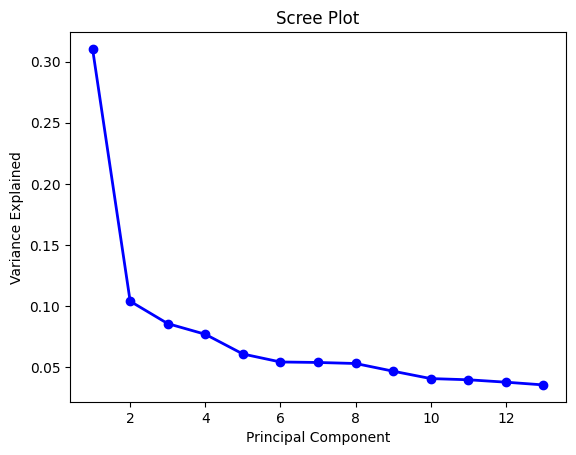

In [16]:
#scree plot using explained variance proportion

PC_values = np.arange(pca.n_components_) + 1
plt.plot(PC_values, pca.explained_variance_ratio_, 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.show()

In [17]:
pca = PCA(n_components=3)
pca_features = pca.fit_transform(df2)
print(pca.explained_variance_ratio_)

[0.310324 0.104008 0.085711]


In [18]:
pca_vectors = pd.DataFrame(data = pca.components_)
pca_vectors.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.274951,0.318954,0.290352,0.322526,0.296504,0.264500,0.099865,0.263154,0.293312,0.264613,0.332240,0.256576,0.254909
1,-0.298014,-0.308210,-0.283398,-0.295617,-0.199199,-0.172311,-0.094818,0.036411,0.242458,0.384863,0.313452,0.387344,0.337059
2,-0.283549,-0.041801,-0.347264,-0.304865,0.375927,0.451242,0.429651,0.389909,-0.039376,-0.043696,-0.049685,-0.075612,-0.105370


In [19]:
pca_df = pd.DataFrame(data=pca_features,columns=['PC1', 'PC2', 'PC3'])
pca_df.describe().apply(lambda s: s.apply('{0:.3f}'.format))

,PC1,PC2,PC3
count,29635.000,29635.000,29635.000
mean,-0.000,-0.000,-0.000
std,2.009,1.163,1.056
min,-2.049,-8.628,-9.413
25%,-1.464,-0.556,-0.566
50%,-0.544,-0.144,-0.132
75%,0.844,0.597,0.589
max,19.235,8.046,6.864


In [20]:
pca_df.corr().apply(lambda s: s.apply('{0:.3f}'.format))

,PC1,PC2,PC3
PC1,1.000,-0.000,-0.000
PC2,-0.000,1.000,0.000
PC3,-0.000,0.000,1.000


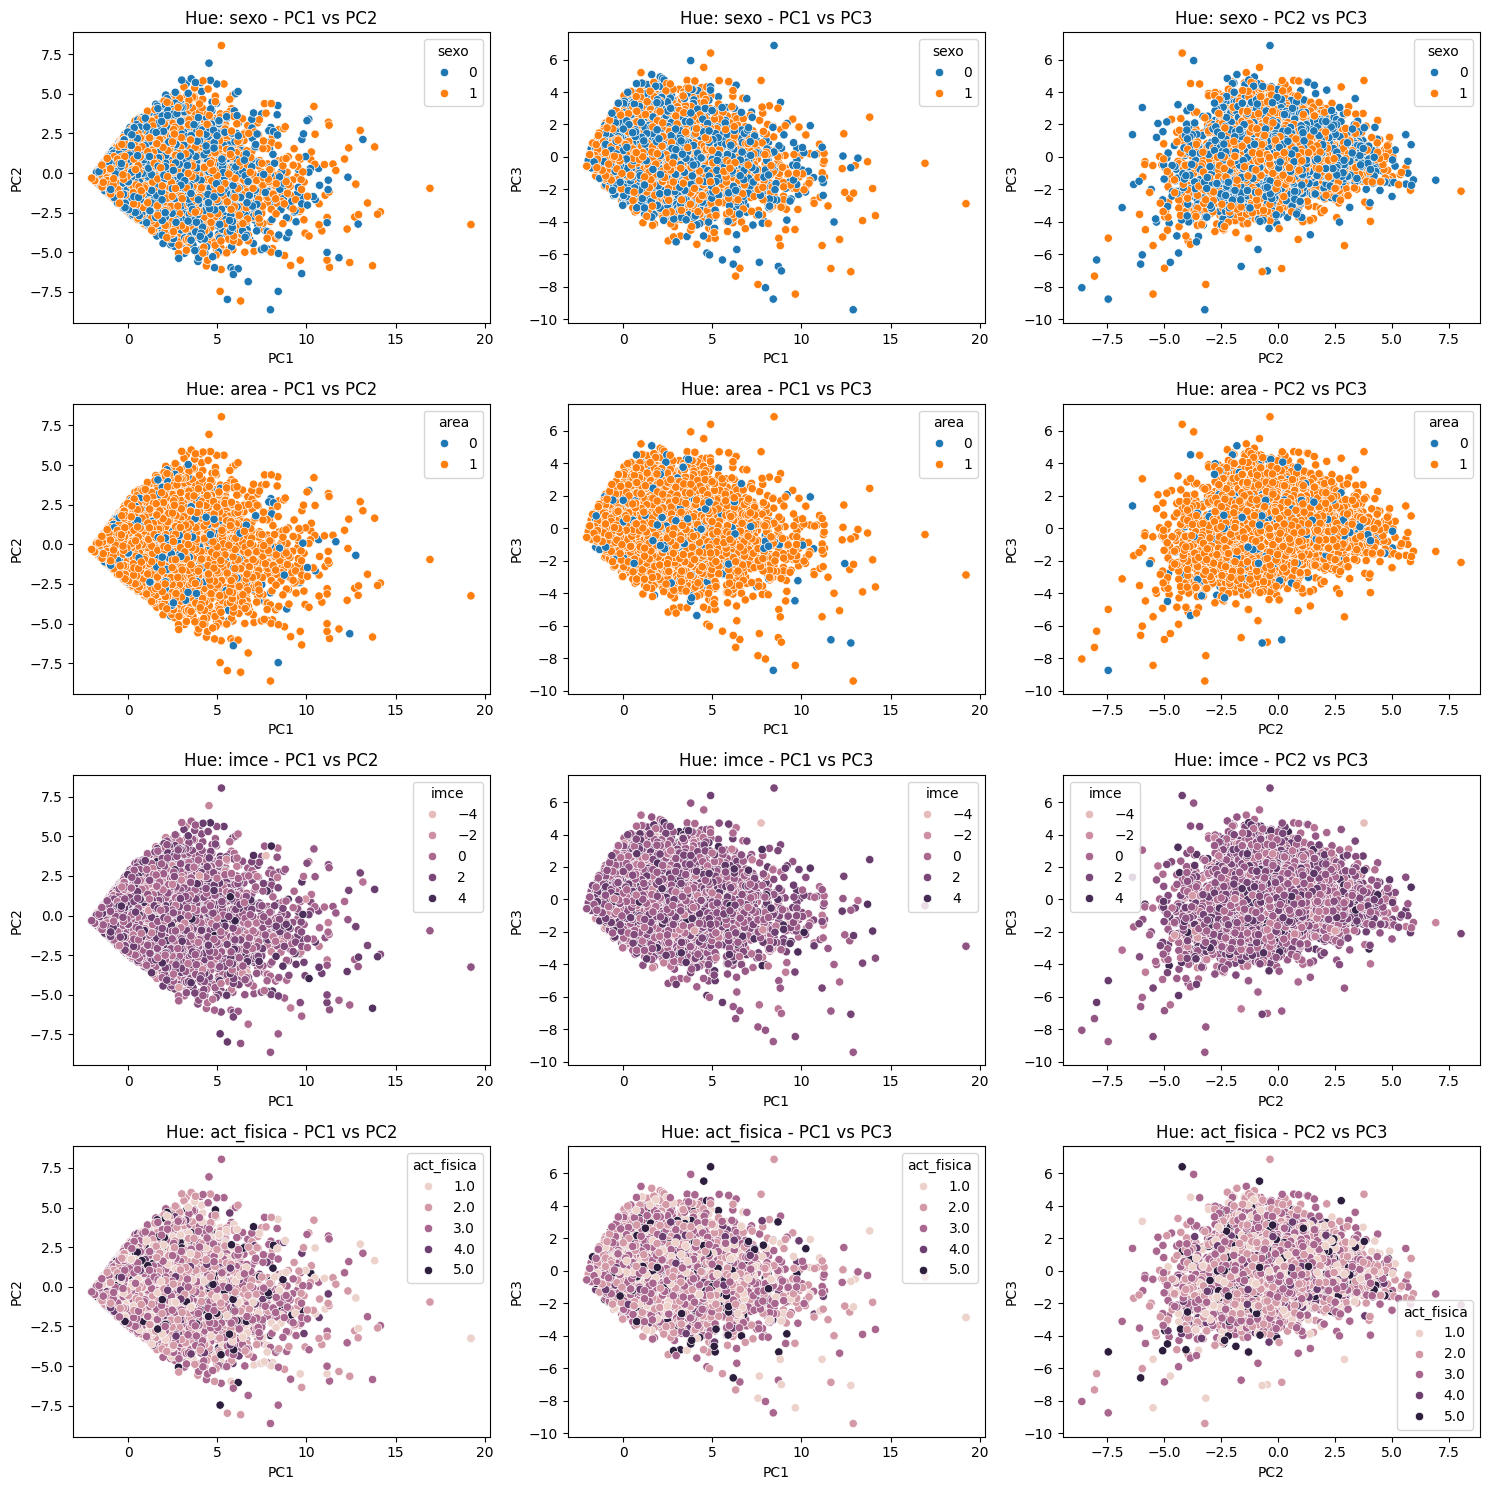

In [21]:
dfa = pd.merge(df, pca_df, left_index=True, right_index=True)
dfa.head()

fig, axes = plt.subplots(4, 3, figsize=(15, 15))  # 4 filas (hues), 3 cols (pares)

# Defino los hues para cada fila (ahora filas cambian hue)
hues = ['sexo', 'area', 'imce', 'act_fisica']

# Defino pares de variables para cada columna
xy_pairs = [('PC1', 'PC2'), ('PC1', 'PC3'), ('PC2', 'PC3')]

for row in range(4):
    for col in range(3):
        ax = axes[row, col]
        hue_var = hues[row]
        x_var, y_var = xy_pairs[col]
        
        sns.scatterplot(data=dfa, x=x_var, y=y_var, hue=hue_var, ax=ax)
        
        ax.set_title(f'Hue: {hue_var} - {x_var} vs {y_var}')
        ax.set_xlabel(x_var)
        ax.set_ylabel(y_var)

plt.tight_layout()
plt.show()


4. Con los resultados obtenidos en la Pregunta 2, proponga un CFA donde cada variable solo se asocia con un factor. Entregue un nombre a cada factor que representa el concepto comun entre las variables incluidas. Reporte la importancia de cada medida (variable) a cada factor e indique la correlacion entre factores (loadings). 

__R:__ Se propuso un modelo el cual consideraba los 3 factores mencionados anteriormente, lo cual nos dio:

Factor1 =~ sk9 + sk10 + sk11 + sk12 + sk13         #Curiosidad intelectual

Factor2 =~ sk1 + sk2 + sk3 + sk4                   #Gestion de emociones

Factor3 =~ sk5 + sk6 + sk8                         #Habilidades sociales

Luego se analizaron las cargas factoriales de cada variable en su factor correspondiente y nos dio que el estimado de las mismas era mayor a 1, por lo cual se llega a la conclusión de que todas explican bien la variabilidad de su factor.

-Tenemos un TLI de 0.933 aprox, lo cual significa que hay un buen ajuste de los datos.

-Tenemos un CFI de 0,948 aprox., lo cual nos indica un ajuste muy bueno de los datos.

-Tenemos un RMSEA de 0.053 aprox. lo cual nos indica que hay un buen ajuste de los datos.

Por las pruebas anteriores, podemos concluir que existe un buen ajuste en los datos.

No esta de mas añadir que todos los valores p de los "sk" son mayores a 0.05, por lo cual son todos significativos.

In [22]:
mod = """
# measurement model
eta1 =~ sk9 + sk10 + sk11 + sk12 + sk13         #Curiosidad intelectual
eta2 =~ sk1 + sk2 + sk3 + sk4                   #Gestion de emociones
eta3 =~ sk5 + sk6 + sk8                         #Habilidades sociales
    """

model = semopy.Model(mod)
out=model.fit(df)
print(out)

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.143
Number of iterations: 41
Params: 1.347 1.246 1.098 1.272 1.876 1.645 1.844 1.021 1.159 0.152 0.049 0.051 0.057 0.160 0.091 0.095 0.596 0.200 0.442 0.714 0.242 0.199 0.158 0.151 0.372 0.470 0.277


In [ ]:
parameters = model.inspect(std_est=True) 
print("--- Cargas factoriales (loadings) ---")
# El operador para los loadings es '~' en esta tabla
loadings = parameters[parameters['op'] == '~']
print(loadings[['lval', 'op', 'rval', 'Estimate', 'Est. Std', 'p-value']].to_string(index=False))

print("\n--- Correlación entre Factores ---")
# El operador para las covarianzas/correlaciones es '~~'
# Filtramos solo las correlaciones entre factores latentes (etaX ~~ etaY donde X != Y)
factor_correlations = parameters[
    (parameters['op'] == '~~') &
    (parameters['lval'].str.startswith('eta')) & # Asegura que lval es un factor (ej. eta1)
    (parameters['rval'].str.startswith('eta')) & # Asegura que rval es un factor
    (parameters['lval'] != parameters['rval']) # Excluye la varianza de los factores consigo mismos
]
# 'Est. Std' en esta tabla representa el coeficiente de correlación estandarizado
print(factor_correlations[['lval', 'op', 'rval', 'Estimate', 'Est. Std', 'p-value']].to_string(index=False))

--- Cargas factoriales (loadings) ---
lval op rval  Estimate  Est. Std p-value
 sk9  ~ eta1  1.000000  0.594873       -
sk10  ~ eta1  1.346839  0.562305     0.0
sk11  ~ eta1  1.245772  0.735504     0.0
sk12  ~ eta1  1.097571  0.541108     0.0
sk13  ~ eta1  1.271792  0.505956     0.0
 sk1  ~ eta2  1.000000  0.583084       -
 sk2  ~ eta2  1.876071  0.644674     0.0
 sk3  ~ eta2  1.645058  0.631947     0.0
 sk4  ~ eta2  1.843514  0.715743     0.0
 sk5  ~ eta3  1.000000  0.717647       -
 sk6  ~ eta3  1.021421  0.556959     0.0
 sk8  ~ eta3  1.158700  0.560768     0.0

--- Correlación entre Factores ---
lval op rval  Estimate  Est. Std p-value
eta2 ~~ eta1  0.051233  0.594859     0.0
eta2 ~~ eta3  0.057348  0.647676     0.0
eta3 ~~ eta1  0.091166  0.584176     0.0


In [24]:
semopy.calc_stats(model)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,51,66,4230.150078,0.0,80730.577968,0.948191,0.947602,0.93219,0.947602,0.932953,0.052585,53.714517,277.725724,0.142742


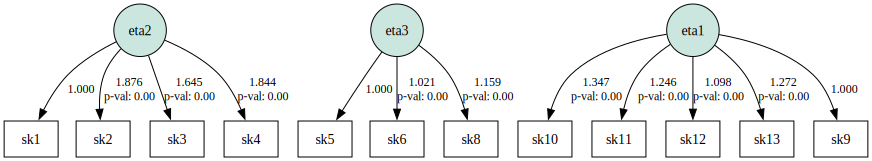

In [25]:
semopy.semplot(model, "model.png")

5. Estime un modelo de clases latentes usando imce via StepMix. Determine el numero optimo de clases (clusters) y muestre las diferencias entre clusters graficamente. Que se puede concluir de los resultados?

__R:__ -Lo primero que se hizo fue un analisis de perfiles latentes para determinar un buen número de clusters, lo cual nos dio como resultado  que lo mejor seria ocupar 4 ya que es donde se encuentra el punto más profundo en el gráfico realizado para el analisis.

-Vemos que el primer cluster tiene valores de media de -2.58 aprox., lo cual podria indicar ciertos niveles de desnutrición en los individuos pertenecientes al mismo.

-En el segundo cluster tenemos valores de media un poco más normales, siendo de 0.132 aprox., lo cual nos indica que los individuos del 2do cluster son de contextura delgada pero no alcanzan niveles de desnutrición.

-En el tercer cluster tenemos que los individuos presentan un imce de media de 1.165 aprox., lo cual nos indica que los individuos de este cluster presentan valores normales en su nutrición, pero algunos rozan el sobrepeso debido a que el rango de este cluster termina en individuos con un imce mayor a 2.

-En el cuarto cluster tenemos que los individuos tienen un imce de media de 2.709, esto nos indica que los individuos de este cluster presentan niveles de sobrepeso alto, llegando incluso algunos a presentar obesidad mórbida.

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:03<00:00,  3.28s/it, max_LL=-5.17e+4, max_avg_LL=-1.74]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:07<00:00,  7.84s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]


Fitting StepMix...


...

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:32<00:00, 32.63s/it, max_LL=-5.12e+4, max_avg_LL=-1.73]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:40<00:00, 40.07s/it, max_LL=-5.12e+4, max_avg_LL=-1.73]


<Axes: >

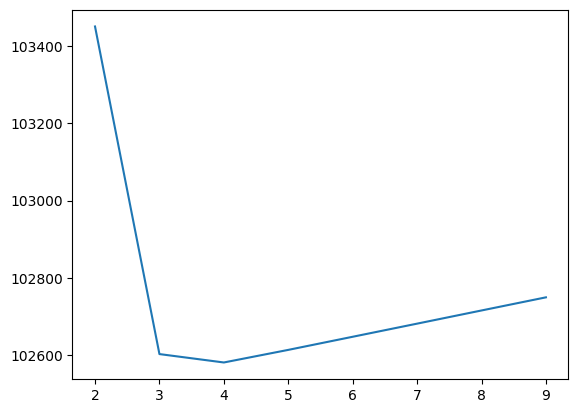

In [26]:
from stepmix.stepmix import StepMix

df_imce=df[['imce']]
# Numero optimo de clusters
K = range(2, 10)
fits = []
BIC = []

for k in K:
    # train the model for current value of k on training data
    model = StepMix(n_components=k, measurement='gaussian', verbose=0, random_state=123).fit(df_imce)
    
    # append the model to fits
    fits.append(model)
    
    # Append the silhouette score to scores
    BIC.append(model.sabic(df_imce))

sns.lineplot(x = K, y = BIC)    

In [27]:

model = StepMix(n_components=4, measurement="gaussian", verbose=1, random_state=123).fit(df_imce)
model.fit(df_imce)
df_imce['pred']=model.predict(df_imce)

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:20<00:00, 20.86s/it, max_LL=-5.12e+4, max_avg_LL=-1.73]


MODEL REPORT
    Measurement model parameters
          model_name     gaussian_unit                        
          class_no                   0       1       2       3
          param variable                                      
          means imce            0.1322 -2.5841  1.1651  2.7091
    Class weights
        Class 1 : 0.34
        Class 2 : 0.01
        Class 3 : 0.49
        Class 4 : 0.16
    Fit for 4 latent classes
    Estimation method             : 1-step
    Number of observations        : 29635
    Number of latent classes      : 4
    Number of estimated parameters: 7
    Log-likelihood (LL)           : -51229.5158
    -2LL                          : 102459.0316
    Average LL                    : -1.7287
    AIC                           : 102473.03
    BIC                           : 102531.11
    CAIC                          : 102538.11
    Sample-Size Adjusted BIC      : 102580.94
    Entropy                       : 22194.0930
    Scaled Relative Entropy    

Initializations (n_init) : 100%|██████████| 1/1 [00:19<00:00, 19.91s/it, max_LL=-5.12e+4, max_avg_LL=-1.73]

MODEL REPORT
    Measurement model parameters
          model_name     gaussian_unit                        
          class_no                   0       1       2       3
          param variable                                      
          means imce            0.1322 -2.5841  1.1651  2.7091
    Class weights
        Class 1 : 0.34
        Class 2 : 0.01
        Class 3 : 0.49
        Class 4 : 0.16
    Fit for 4 latent classes
    Estimation method             : 1-step
    Number of observations        : 29635
    Number of latent classes      : 4
    Number of estimated parameters: 7
    Log-likelihood (LL)           : -51229.5158
    -2LL                          : 102459.0316
    Average LL                    : -1.7287
    AIC                           : 102473.03
    BIC                           : 102531.11
    CAIC                          : 102538.11
    Sample-Size Adjusted BIC      : 102580.94
    Entropy                       : 22194.0930
    Scaled Relative Entropy    

In [28]:
means = model.get_parameters()['measurement']['means'].flatten()
df_imce['pred'] = df_imce['pred'].map(dict(enumerate(means)))


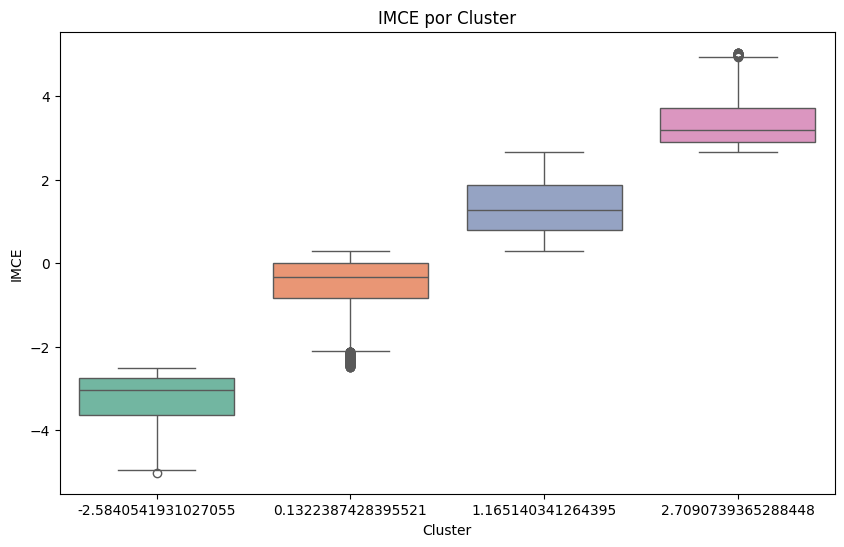

In [32]:
plt.figure(figsize=(10,6))
sns.boxplot(
    x='pred', 
    y='imce', 
    data=df_imce, 
    palette='Set2'
)
plt.title('IMCE por Cluster')
plt.xlabel('Cluster')
plt.ylabel('IMCE')
plt.show()
               

6. Implemente un SEM completo usando la estructura propuesta en la Pregunta 4. En particular, estime un modelo donde los factores latentes explican el imce, junto con otras variables que existen en la base de datos. Ademas utilice otras variables relevantes de la base de datos para su modelo. Las variables a incluir en el modelo final deben tener sustento teorico y el modelo final debe optimizar el ajuste a los datos, en base a los criterios vistos en clase (TLI, CLI, RMSEA). Que puede concluir en base a sus resultados?

__R:__ Se propuso un modelo el cual consideraba de forma obligatoria los 3 factores mencionados anteriormente, además se consideraron variables que resultaban ser significativas para la base de datos, para verificar lo anterior se corrio el modelo varias veces hasta quedarnos con las variables que tenian un valor p menor o igual a 0.05.

Seguido del paso anterior, se siguieron eliminando ciertas variables y probando el modelo hasta que los valores de los criterios TLI y CLI fueran mayores o iguales a 0.90, pero solo se logro un ajuste máximo de 0.88 en el TLI.

El modelo que quedo como resultado fue:

imce = eta1 + eta2 + eta3 + sexo + area + madre_work + act_fisica 

-Tenemos un TLI de 0.88 aprox, lo cual significa que hay un ajuste medianamente aceptable de los datos

-Tenemos un CFI de 0,90 aprox., lo cual nos indica un buen ajuste de los datos

-Tenemos un RMSEA de 0.05 aprox. lo cual nos indica que hay un buen ajuste de los datos.

El valor p del factor 1 es de 0.47, lo cual nos indica que la curiosidad intelectual no es significativa a la hora de determinar el imce de un niño.

In [33]:
mod_cf = '''
#Measurement
eta1 =~ sk9 + sk10 + sk11 + sk12 + sk13         #Curiosidad intelectual
eta2 =~ sk1 + sk2 + sk3 + sk4                   #Gestion de emociones
eta3 =~ sk5 + sk6 + sk8                         #Habilidades sociales

#Structural
imce ~ eta1 + eta2 + eta3 + sexo + area + madre_work + act_fisica 
'''

model_cfa = semopy.Model(mod_cf);
out = model_cfa.fit(df);
print(out)

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.300
Number of iterations: 51
Params: 1.345 1.244 1.097 1.270 1.880 1.647 1.847 1.022 1.160 -0.025 -0.307 0.240 0.134 -0.170 0.032 -0.025 0.152 0.049 0.051 0.057 0.160 0.091 1.863 0.095 0.596 0.200 0.442 0.714 0.242 0.199 0.158 0.151 0.372 0.469 0.277


In [34]:
semopy.calc_stats(model_cfa)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,118,140,8898.287159,0.0,86148.584303,0.897914,0.89671,0.877453,0.89671,0.878881,0.050109,69.399474,359.784373,0.300263


In [35]:
model_cfa.inspect(mode='list', what="names", std_est=True)

,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,sk9,~,eta1,1.000000,0.595334,-,-,-
1,sk10,~,eta1,1.345261,0.562159,0.018513,72.667369,0.0
2,sk11,~,eta1,1.244368,0.735423,0.014698,84.660528,0.0
3,sk12,~,eta1,1.096556,0.541141,0.015507,70.713756,0.0
4,sk13,~,eta1,1.270138,0.505823,0.018884,67.259202,0.0
5,sk1,~,eta2,1.000000,0.582515,-,-,-
6,sk2,~,eta2,1.879711,0.645021,0.023845,78.831096,0.0
7,sk3,~,eta2,1.647230,0.632019,0.021152,77.875668,0.0
8,sk4,~,eta2,1.846951,0.716096,0.022201,83.193471,0.0
9,sk5,~,eta3,1.000000,0.717465,-,-,-


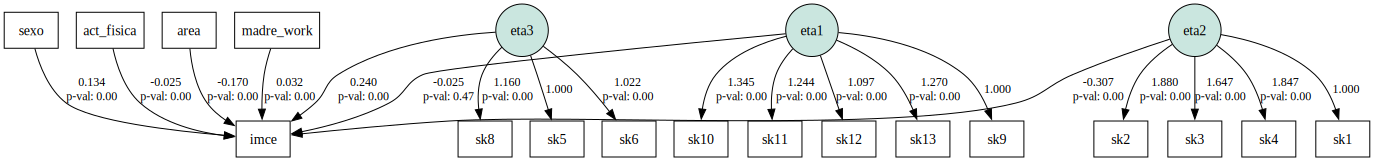

In [36]:
semopy.semplot(model_cfa, "semmodel.png")

7. Repita el analisis de la Pregunta 6 usando para cada submuestra generada a partir de las clases latentes obtenida en la pregunta 5. Reporte diferencias entre los parametros entre los distintos grupos (si existieran). Hay alguna ganancia de estimar el modelo por grupos versus el modelo general?  

__R:__ Se realizo un analisis igual al de la pregunta anterior para cada cluster, cabe aclarar que los valores de los TLI, CFI y RMSEA siguen siendo los mismos debido a que no se modifico el modelo, solo se cambio la muestra de estudio, estos fueron los resultados:

__Cluster 1:__

-El factor que nos indica la curiosidad intelectual no es significativo, teniendo este un valor p de 0.81
-El factor que nos indica la gestion de las emociones tampoco es significativo, teniendo este un valor p de 0.11

__Cluster 2:__

-El factor que nos indica la curiosidad intelectual no es significativo, teniendo este un valor p de 0.19
-El factor que nos indica la gestion de las emociones tampoco es significativo, teniendo este un valor p de 0.16
-La actividad fisica no es una variable significativa en este cluster, teniendo esta un valor p de 0.76
-El area urbana en la que vive el niño tampoco es significativa en este cluster, teniendo un valor p de 0.79

__Cluster 3:__

-El factor que nos indica la curiosidad intelectual no es significativo, teniendo este un valor p de 0.59
-El factor que nos indica la gestion de las emociones tampoco es significativo, teniendo este un valor p de 0.55
-El factor que nos indica las habilidades sociales tampoco es significativo, teniendo este un valor p de 0.50
-El trabajo de la madre resulta no ser significativo en este cluster, teniendo un valor p de 0.72
-La actividad fisica tampoco es una variable significativa en este cluster, teniendo esta un valor p de 0.41
-El area urbana en la que vive el niño tampoco es significativa en este cluster, teniendo un valor p de 0.60

__Cluster 4:__

-El factor que nos indica la curiosidad intelectual no es significativo, teniendo este un valor p de 0.74
-El factor que nos indica la gestion de las emociones tampoco es significativo, teniendo este un valor p de 0.76
-El factor que nos indica las habilidades sociales tampoco es significativo, teniendo este un valor p de 0.73
-El trabajo de la madre resulta no ser significativo en este cluster, teniendo un valor p de 0.31
-El sexo del individuo no resulta ser relevante en este cluster, teniendo un valor p de 0.23
-El area urbana en la que vive el niño tampoco es significativa en este cluster, teniendo un valor p de 0.22

Se llega a la conclusion de que el modelo pierde efectividad a medida que va subiendo el imce de la muestra estudiada, por lo cual no hay ninguna ganancia a la hora de realizar el modelado por grupos y conviene más ocupar el modelo general para todo el dataframe.

In [37]:
df["pred"]=df_imce["pred"]
clusters = df['pred'].unique()  # o range(4) si ya sabés que son 4
dfs_por_cluster = {k: df[df['pred'] == k] for k in clusters}
lista_clusters = list(dfs_por_cluster.keys())

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.308
Number of iterations: 40
Params: 1.360 1.250 1.096 1.265 1.917 1.669 1.827 1.024 1.184 -0.005 -0.072 0.067 0.031 -0.034 0.014 -0.015 0.147 0.047 0.050 0.056 0.156 0.090 0.421 0.091 0.582 0.194 0.443 0.711 0.233 0.201 0.162 0.151 0.376 0.449 0.275


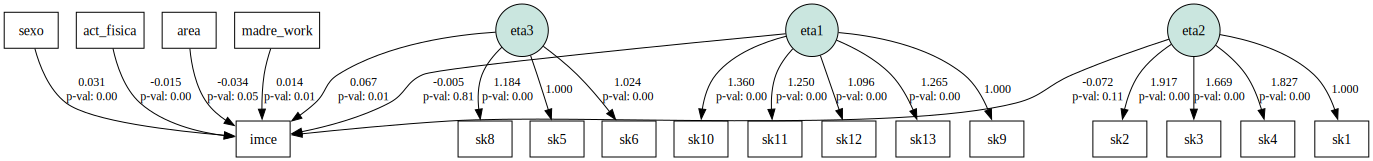

In [38]:
mod_cf = '''
#Measurement
eta1 =~ sk9 + sk10 + sk11 + sk12 + sk13         #Curiosidad intelectual
eta2 =~ sk1 + sk2 + sk3 + sk4                   #Gestion de emociones
eta3 =~ sk5 + sk6 + sk8                         #Habilidades sociales

#Structural
imce ~ eta1 + eta2 + eta3 + sexo + area + madre_work + act_fisica 
'''

model_cfa1 = semopy.Model(mod_cf);
out = model_cfa1.fit(dfs_por_cluster[lista_clusters[0]]);
print(out)

semopy.semplot(model_cfa1, "semmodel.png")

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.364
Number of iterations: 38
Params: 1.357 1.226 1.146 1.340 1.793 1.449 1.668 0.967 1.060 -0.051 -0.105 0.139 0.178 -0.009 -0.020 -0.003 0.171 0.060 0.055 0.071 0.203 0.105 0.327 0.097 0.658 0.224 0.464 0.756 0.250 0.212 0.157 0.177 0.395 0.544 0.282


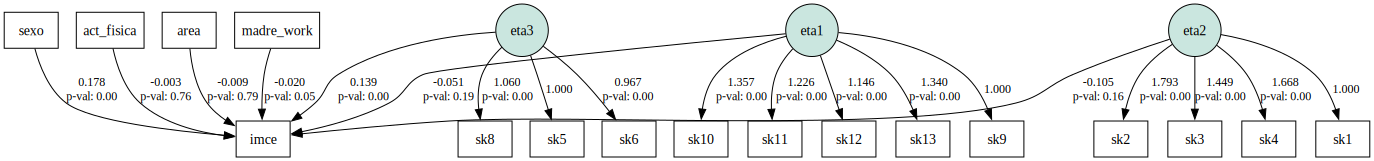

In [39]:
mod_cf = '''
#Measurement
eta1 =~ sk9 + sk10 + sk11 + sk12 + sk13         #Curiosidad intelectual
eta2 =~ sk1 + sk2 + sk3 + sk4                   #Gestion de emociones
eta3 =~ sk5 + sk6 + sk8                         #Habilidades sociales

#Structural
imce ~ eta1 + eta2 + eta3 + sexo + area + madre_work + act_fisica 
'''

model_cfa2 = semopy.Model(mod_cf);
out = model_cfa2.fit(dfs_por_cluster[lista_clusters[1]]);
print(out)

semopy.semplot(model_cfa2, "semmodel.png")

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.300
Number of iterations: 41
Params: 1.313 1.250 1.088 1.254 1.815 1.679 1.952 1.046 1.157 0.016 -0.034 -0.022 -0.051 -0.013 -0.003 0.005 0.152 0.048 0.051 0.054 0.152 0.087 0.368 0.102 0.593 0.201 0.431 0.696 0.257 0.188 0.151 0.141 0.356 0.474 0.279


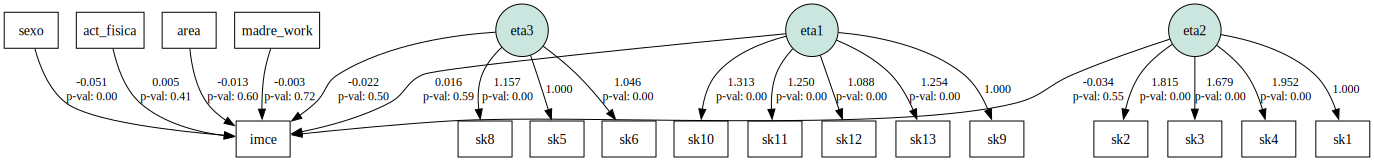

In [40]:
mod_cf = '''
#Measurement
eta1 =~ sk9 + sk10 + sk11 + sk12 + sk13         #Curiosidad intelectual
eta2 =~ sk1 + sk2 + sk3 + sk4                   #Gestion de emociones
eta3 =~ sk5 + sk6 + sk8                         #Habilidades sociales

#Structural
imce ~ eta1 + eta2 + eta3 + sexo + area + madre_work + act_fisica 
'''

model_cfa3 = semopy.Model(mod_cf);
out = model_cfa3.fit(dfs_por_cluster[lista_clusters[2]]);
print(out)

semopy.semplot(model_cfa3, "semmodel.png")

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.820
Number of iterations: 46
Params: 1.122 1.070 0.812 1.102 3.323 2.792 2.824 0.871 1.168 -0.039 0.247 -0.189 -0.109 0.233 0.047 0.110 0.245 0.019 0.037 0.043 0.188 0.089 0.400 0.095 0.736 0.190 0.379 0.863 0.169 0.193 0.119 0.137 0.408 0.660 0.311


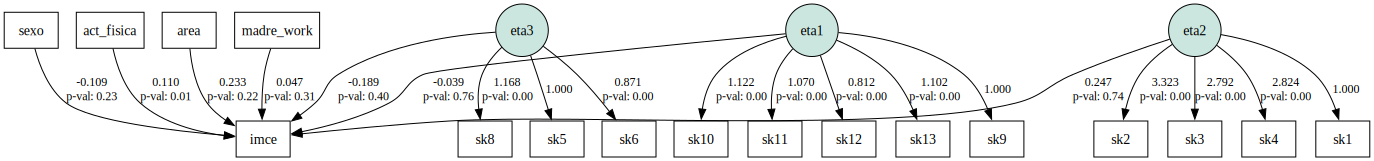

In [41]:
mod_cf = '''
#Measurement
eta1 =~ sk9 + sk10 + sk11 + sk12 + sk13         #Curiosidad intelectual
eta2 =~ sk1 + sk2 + sk3 + sk4                   #Gestion de emociones
eta3 =~ sk5 + sk6 + sk8                         #Habilidades sociales

#Structural
imce ~ eta1 + eta2 + eta3 + sexo + area + madre_work + act_fisica 
'''

model_cfa4 = semopy.Model(mod_cf);
out = model_cfa4.fit(dfs_por_cluster[lista_clusters[3]]);
print(out)

semopy.semplot(model_cfa4, "semmodel.png")